**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Aarón Hernández Jiménez
*   MATRÍCULA: A01642529


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [1]:
# Importa las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [2]:
weather_df = pd.read_csv('cleaned_weather.csv')

print(weather_df.shape)
weather_df.columns

(52696, 13)


Index(['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv',
       'wd', 'rain', 'raining'],
      dtype='str')

In [3]:
weather_df.columns = ['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin',
                      'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor',
                      'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total',
                      'duracion_lluvia']
weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [4]:
weather_df.tail()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [5]:
weather_df.isna().sum()

medicion               0
presion_atmosferica    0
temperatura_celsius    0
temperatura_kelvin     0
humedad_relativa       0
presion_vapor          0
humedad_especifica     0
concentracion_vapor    0
densidad_aire          0
velocidad_viento       0
direccion_viento       0
precipitacion_total    0
duracion_lluvia        0
dtype: int64

El dataframe tiene 52,696 registros y 13 columnas. **No hay valores faltantes**: `isna().sum()` devuelve 0 en todas las columnas.

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [6]:
weather_df.dtypes

medicion                   str
presion_atmosferica    float64
temperatura_celsius    float64
temperatura_kelvin     float64
humedad_relativa       float64
presion_vapor          float64
humedad_especifica     float64
concentracion_vapor    float64
densidad_aire          float64
velocidad_viento       float64
direccion_viento       float64
precipitacion_total    float64
duracion_lluvia          int64
dtype: object

`medicion` se leyó como texto, `duracion_lluvia` como entero (`int64`) y las demás columnas como flotantes (`float64`).

In [7]:
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'], format='%d/%m/%y %H:%M')
weather_df['fecha'] = weather_df['medicion'].dt.date
weather_df['hora'] = weather_df['medicion'].dt.time
weather_df[['medicion', 'fecha', 'hora']].head()

,medicion,fecha,hora
0,2020-01-01 00:10:00,2020-01-01,00:10:00
1,2020-01-01 00:20:00,2020-01-01,00:20:00
2,2020-01-01 00:30:00,2020-01-01,00:30:00
3,2020-01-01 00:40:00,2020-01-01,00:40:00
4,2020-01-01 00:50:00,2020-01-01,00:50:00


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [8]:
weather_df.nunique()

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64

In [9]:
display(weather_df[weather_df.duplicated(subset=['medicion'], keep=False)])

weather_df = weather_df.drop_duplicates()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00


La fecha duplicada es **12/05/2020 06:00**. Las dos filas tienen los mismos valores en todas las columnas, así que `drop_duplicates()` (que compara la fila completa) eliminó uno de los registros.

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [10]:
weather_df.nunique()

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64

Las mediciones se registran cada 10 minutos, es decir, 6 por hora. En un día hay 24 × 6 = **144** horarios posibles (de `00:00` a `23:50`), y todos aparecen al menos una vez en el año.

In [11]:
rango_completo = pd.date_range(start=weather_df['medicion'].min(), end=weather_df['medicion'].max(), freq='10min')
mediciones_faltantes = rango_completo.difference(weather_df['medicion'])
mediciones_faltantes

DatetimeIndex(['2020-05-29 09:40:00', '2020-05-29 09:50:00',
               '2020-05-29 10:00:00', '2020-05-29 10:10:00',
               '2020-05-29 10:20:00', '2020-05-29 10:30:00',
               '2020-05-29 10:40:00', '2020-05-29 10:50:00',
               '2020-05-29 11:00:00'],
              dtype='datetime64[us]', freq='10min')

In [12]:
pd.Series(mediciones_faltantes.date).value_counts()

2020-05-29    9
Name: count, dtype: int64

Con mediciones cada 10 minutos entre el 01/01/2020 00:10 y el 01/01/2021 00:00 deberían existir 52,704 registros, pero hay 52,695. Las **9 mediciones faltantes** están todas en la fecha **29/05/2020**, de las 09:40 a las 11:00, y corresponden a un hueco continuo de 90 minutos en el registro de la estación.

In [13]:
weather_df = weather_df[weather_df['medicion'].dt.year == 2020].drop(columns='medicion')
weather_df.shape

(52694, 14)

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [14]:
indicadores_diarios = weather_df.drop(columns='hora').groupby('fecha').max()
indicadores_diarios.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
fecha,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0
2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0
2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470
2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600
2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0


In [15]:
indicadores_diarios['precipitacion_total'].agg(['max', 'idxmax'])

max             11.2
idxmax    2020-06-16
Name: precipitacion_total, dtype: object

La máxima precipitación fue de **11.2 mm**, el **16/06/2020**.

In [16]:
indicadores_diarios['velocidad_viento'].nlargest(3)

fecha
2020-02-10    13.77
2020-02-16    13.00
2020-02-09    12.52
Name: velocidad_viento, dtype: float64

Los tres días con las velocidades de viento más altas fueron el **10/02/2020 (13.77 m/s)**, el **16/02/2020 (13.00 m/s)** y el **09/02/2020 (12.52 m/s)**. Los tres son de febrero.

In [17]:
dias_calor_y_humedad = ((indicadores_diarios['humedad_relativa'] > 90) & (indicadores_diarios['temperatura_celsius'] > 30)).sum().item()
dias_calor_y_humedad

5

**5 días** rebasaron tanto el 90% de humedad relativa como los 30 °C. Por separado, 221 días superaron el 90% de humedad y solo 9 superaron los 30 °C. Como `indicadores_diarios` guarda el máximo de cada indicador, estos valores suelen darse a horas distintas (la humedad alta de madrugada y la temperatura alta por la tarde), así que esos 5 días no necesariamente tuvieron calor y humedad al mismo tiempo.

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [18]:
indicadores_diarios.describe()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


- **Desviación estándar de `concentracion_vapor`:** Es de **4.57 mmol/mol**. Esta variación es bastante grande, ya que representa casi el 40% respecto a su promedio (que es de 11.54 mmol/mol). En el mundo real, esta gran fluctuación se explica por el cambio de las estaciones: el aire caliente del verano tiene la capacidad de retener mucho más vapor de agua que el aire frío del invierno, haciendo que los valores suban y bajen drásticamente a lo largo del año.
- **Mediana de `presion_atmosferica`:** Es de **993.3 mbar**. La mediana nos dice que exactamente la mitad de los días del año (el 50%) tuvieron una presión por debajo de 993.3 mbar, y la otra mitad estuvieron por encima. Lo interesante aquí es que la mediana es casi idéntica a la media (992.98 mbar), lo que indica una distribución aproximadamente simétrica: sí hay días de presión muy baja (959.9 mbar) y muy alta (1020.07 mbar), pero se compensan entre sí y no jalan el promedio hacia ningún lado.
- **Tercer cuartil de `duracion_lluvia`:** El valor de 600 segundos equivale exactamente a 10 minutos, que es la duración de un intervalo completo de medición. Que el tercer cuartil sea 600 s significa que el 75% de los días registraron ráfagas de lluvia de 10 minutos o menos. Viéndolo al revés, nos dice que por lo menos un 25% de los días del año llovió sin parar durante todo un intervalo de medición completo.

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

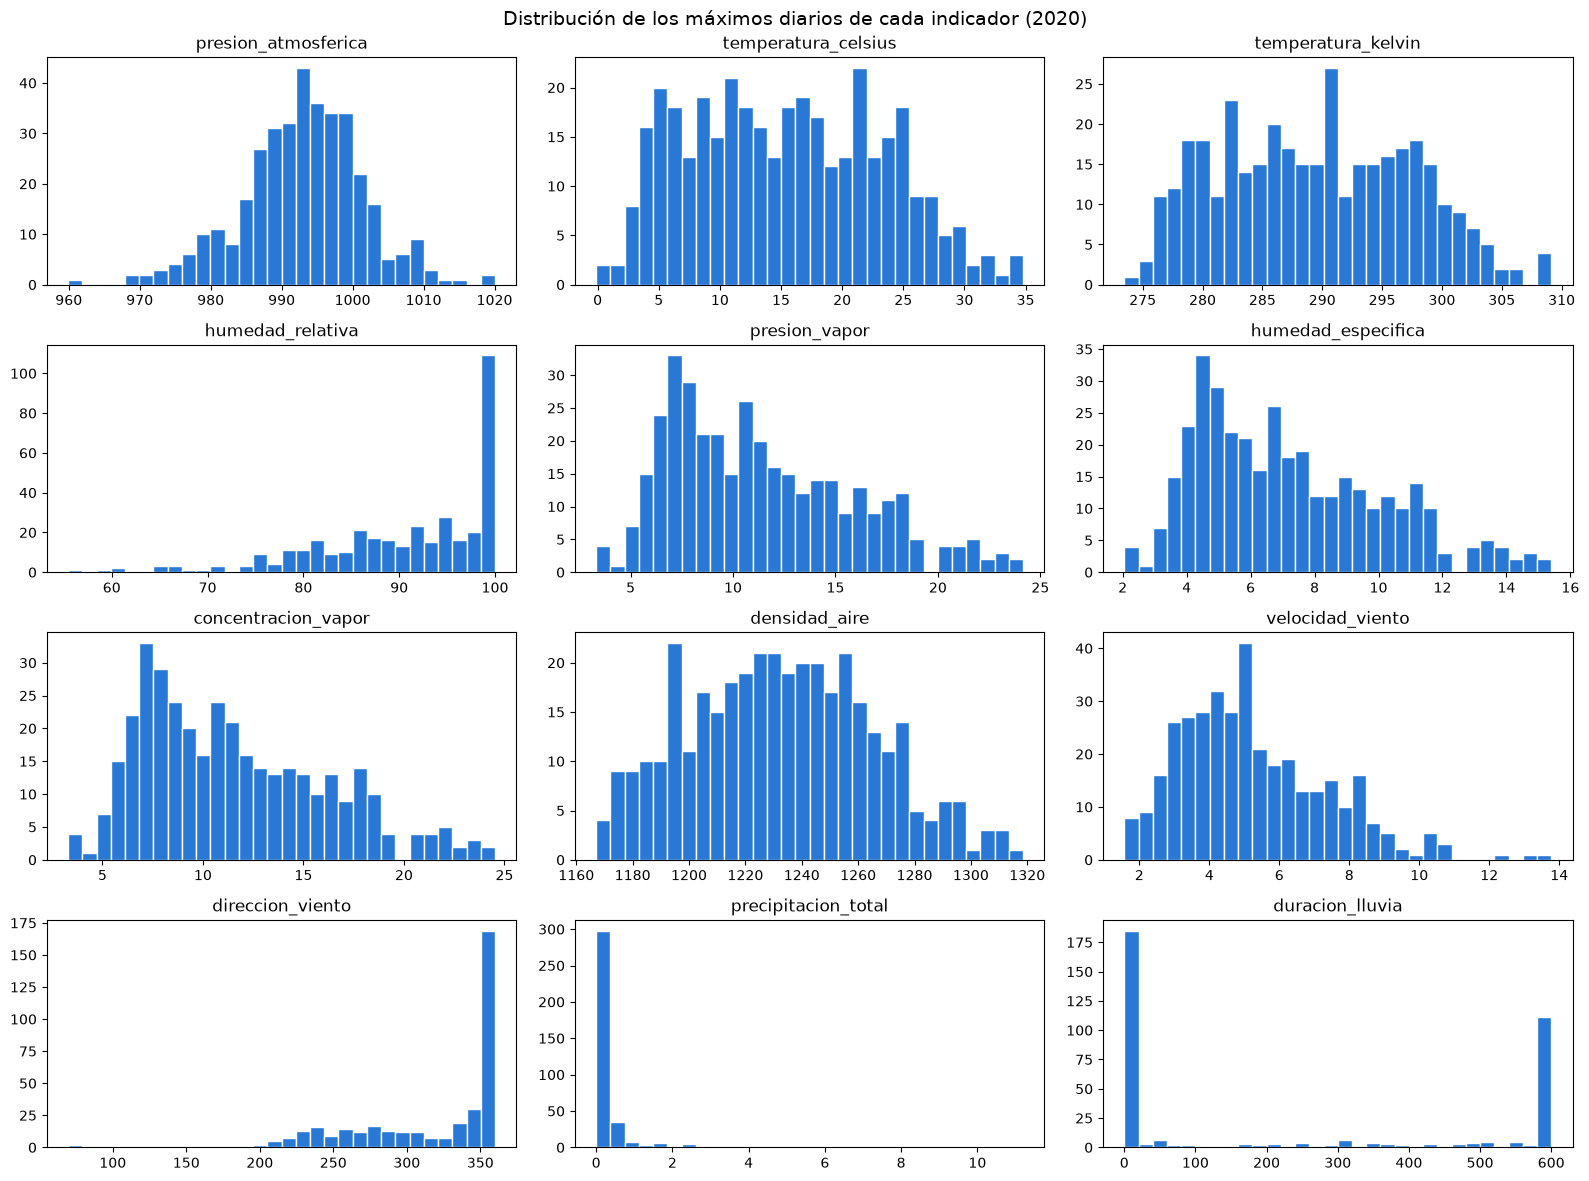

In [19]:
indicadores_diarios.hist(figsize=(16, 12), bins=30, layout=(4, 3), color='#2a78d6', edgecolor='white', grid=False)
plt.suptitle('Distribución de los máximos diarios de cada indicador (2020)', fontsize=14)
plt.tight_layout()
plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [20]:
# 1. Crear la columna 'mes' convirtiendo primero el índice a DatetimeIndex
indicadores_diarios['mes'] = pd.to_datetime(indicadores_diarios.index).month

# 2. Agrupar por mes, seleccionar las 3 columnas de interés (doble corchete) y promediar
indicadores_mensuales = indicadores_diarios.groupby('mes')[['humedad_relativa', 'temperatura_celsius', 'velocidad_viento']].mean()

# 3. Mostrar el resultado
display(indicadores_mensuales)

,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
1,89.776129,6.821290,5.031935
2,85.719655,8.962414,7.489655
3,85.372903,9.683871,6.421290
4,80.938667,16.879667,4.997000
5,87.464839,17.135484,4.865806
6,94.256000,22.212000,5.296667
7,85.959355,24.336129,4.830323
8,92.002581,26.097742,5.040323
9,97.570000,21.571667,4.153333


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [21]:
indicadores_mensuales_pivot = indicadores_diarios.pivot_table(index='mes', values=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento'], aggfunc='mean')
indicadores_mensuales_pivot.equals(indicadores_mensuales)

True

`equals()` devuelve `True`: el dataframe construido con `pivot_table()` tiene la misma estructura (índice `mes`, mismas columnas en el mismo orden) y los mismos valores que el obtenido con `groupby()`.

In [22]:
indicadores_mensuales_pivot['indice_calor'] = (indicadores_mensuales_pivot['temperatura_celsius']
                                               + 0.33 * indicadores_mensuales_pivot['humedad_relativa']
                                               - 0.7 * indicadores_mensuales_pivot['velocidad_viento'] - 4)
indicadores_mensuales_pivot

,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
mes,,,,
1,89.776129,6.821290,5.031935,28.925058
2,85.719655,8.962414,7.489655,28.007141
3,85.372903,9.683871,6.421290,29.362026
4,80.938667,16.879667,4.997000,36.091527
5,87.464839,17.135484,4.865806,38.592816
6,94.256000,22.212000,5.296667,45.608813
7,85.959355,24.336129,4.830323,45.321490
8,92.002581,26.097742,5.040323,48.930368
9,97.570000,21.571667,4.153333,46.862433


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [23]:
mensuales_melt = indicadores_mensuales_pivot.reset_index().melt(id_vars='mes', var_name='indicador', value_name='valor')
print(type(mensuales_melt), mensuales_melt.shape)
mensuales_melt.head(8)

<class 'pandas.DataFrame'> (48, 3)


,mes,indicador,valor
0,1,humedad_relativa,89.776129
1,2,humedad_relativa,85.719655
2,3,humedad_relativa,85.372903
3,4,humedad_relativa,80.938667
4,5,humedad_relativa,87.464839
5,6,humedad_relativa,94.256000
6,7,humedad_relativa,85.959355
7,8,humedad_relativa,92.002581


In [24]:
mensuales_stack = indicadores_mensuales_pivot.stack()
print(type(mensuales_stack), mensuales_stack.shape)
mensuales_stack.head(8)

<class 'pandas.Series'> (48,)


mes                     
1    humedad_relativa       89.776129
     temperatura_celsius     6.821290
     velocidad_viento        5.031935
     indice_calor           28.925058
2    humedad_relativa       85.719655
     temperatura_celsius     8.962414
     velocidad_viento        7.489655
     indice_calor           28.007141
dtype: float64

**Diferencias principales entre `melt()` y `stack()`:**

* **Tipo de objeto y estructura:** `melt()` genera un nuevo **DataFrame** tradicional (tabla bidimensional), mientras que `stack()` comprime los datos en una **Series** de una sola dimensión apoyada en un índice múltiple (MultiIndex).
* **Ubicación del mes:** Para usar `melt()`, el `mes` debe ser una **columna normal** (por eso usamos `reset_index()`). `stack()` conserva `mes` en el índice como nivel exterior y convierte los nombres de las columnas (los 4 indicadores) en un **nuevo nivel interior** del índice.
* **Ordenamiento de las filas:** `melt()` ordena los resultados agrupando por **indicador** (enlista todos los valores de humedad de enero a diciembre, luego todos los de temperatura, etc.). En contraste, `stack()` agrupa por **mes** (muestra enero con sus 4 indicadores, luego febrero con sus 4, y así sucesivamente).
* **Control y personalización:** `melt()` es más explícito y permite nombrar las nuevas columnas al momento (usando `var_name` y `value_name`) y elegir cuáles conservar como identificadores. `stack()` es una acción directa que siempre toma el nivel inferior de las columnas y lo apila en el índice.

**¿Cuándo usar cada uno?**
El formato largo y tabular de `melt()` (conocido como *tidy data*) es la estructura que esperan librerías de visualización como **Seaborn y Plotly**. `stack()` conviene cuando se quiere seguir trabajando con el índice jerárquico dentro de pandas, por ejemplo para seleccionar u operar por niveles, y es reversible con `unstack()` para volver al formato ancho.

---

**Declaración de uso de IA**

*   Anthropic. (2026). *Claude (Opus 5.5)* [Modelo de lenguaje grande], depuración, redacción de respuestas y revisión de interpretaciones. https://claude.ai/

---
